In [1]:
# Importation de PyTorch pour le deep learning
import torch

# Module pour construire des couches de réseaux de neurones (Linear, Conv, etc.)
import torch.nn as nn

# Fonctions utiles (activation, loss functions, etc.)
import torch.nn.functional as F

In [2]:
# Définition d'un bloc de Self-Attention simple
class SimpleSelfAttention(nn.Module):

    def __init__(self, embed_size):
        super(SimpleSelfAttention, self).__init__()

        # Taille des embeddings (dimension des vecteurs)
        self.embed_size = embed_size

        # Couche linéaire pour générer les Query (Q)
        self.query = nn.Linear(embed_size, embed_size)

        # Couche linéaire pour générer les Key (K)
        self.key = nn.Linear(embed_size, embed_size)

        # Couche linéaire pour générer les Value (V)
        self.value = nn.Linear(embed_size, embed_size)

    def forward(self, x):

        # Calcul des matrices Q, K, V
        Q = self.query(x)
        K = self.key(x)
        V = self.value(x)

        # Calcul des scores d'attention (Q × K^T)
        attention_scores = torch.matmul(Q, K.transpose(-2, -1))

        # Normalisation des scores
        attention_scores = attention_scores / (self.embed_size ** 0.5)

        # Softmax pour obtenir des poids d'attention
        attention_weights = F.softmax(attention_scores, dim=-1)

        # Application des poids sur les valeurs V
        output = torch.matmul(attention_weights, V)

        # Retourne la sortie et les poids d'attention
        return output, attention_weights

In [3]:
# Définition des hyperparamètres
embed_size = 16   # dimension des embeddings
seq_len = 5       # longueur de la séquence
batch_size = 1    # taille du batch

# Création d'un tenseur d'entrée aléatoire
# shape = (batch_size, seq_len, embed_size)
x = torch.rand(batch_size, seq_len, embed_size)

# Initialisation du modèle de self-attention
model = SimpleSelfAttention(embed_size)

# Passage forward dans le modèle
output, weights = model(x)

# Affichage des dimensions de sortie
print("Output shape:", output.shape)
print("Attention shape:", weights.shape)

Output shape: torch.Size([1, 5, 16])
Attention shape: torch.Size([1, 5, 5])


In [4]:
# Affichage de la matrice d'attention pour le premier élément du batch
# weights[0] correspond à la matrice attention de la séquence unique
print(weights[0])

tensor([[0.1902, 0.2000, 0.2083, 0.1930, 0.2084],
        [0.1879, 0.1989, 0.1951, 0.1967, 0.2214],
        [0.1927, 0.1970, 0.2017, 0.1981, 0.2106],
        [0.1885, 0.2002, 0.2066, 0.1927, 0.2120],
        [0.1826, 0.2062, 0.1995, 0.1945, 0.2173]], grad_fn=<SelectBackward0>)


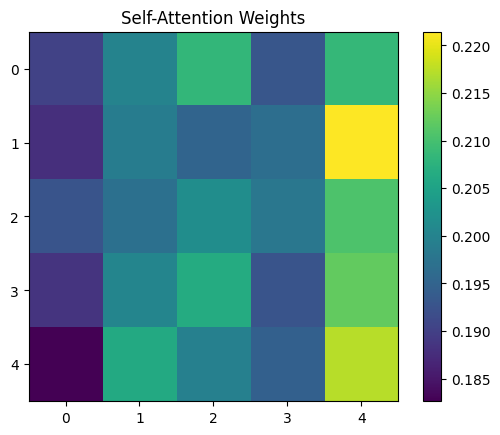

In [5]:
# Importation des bibliothèques pour visualisation et gestion des fichiers
import matplotlib.pyplot as plt
import os

# Création du dossier si nécessaire pour sauvegarder les images
os.makedirs("../images/attention_maps", exist_ok=True)

# Création d'une figure pour afficher la matrice d'attention
plt.figure()

# Affichage de la matrice des poids d'attention
plt.imshow(
    weights[0].detach().numpy(),
    cmap="viridis"
)

# Titre du graphique
plt.title("Self-Attention Weights")

# Ajout de la barre de couleur
plt.colorbar()

# Sauvegarde de l'image générée
plt.savefig("../images/attention_maps/self_attention_weights.png")

# Affichage du graphique
plt.show()